In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Previsão de Churn para Clientes do Banco
## Bank Customer Churn
"Your task is to predict whether a customer continues with their account or closes it."
kaggle.

Dataset original:
https://www.kaggle.com/competitions/bank-customer-churn-ict-u-ai/overview



#Etapas do Projeto:

**1- O problema de negócio:** objetivo principal do projeto e como ele gera valor ao banco.

**2- Coleta e entendimento dos dados:** subir no github e validar importação.

**3- Dividir os dados em conjuntos de treino e teste:** Separar uma parte dos dados para ensinar o algoritmo e outra parte isolada para validar sua capacidade de generalização.

**4- Análise exploratória de dados - EDA:** Identificar padrões visuais, distribuições, outliers e entender como as variáveis se relacionam com o alvo.

**5- Engenharia de features, limpeza de dados e pré-processamento:** Tratar valores nulos, codificar categorias e criar novas variáveis calculadas para facilitar o aprendizado do algoritmo.

**6- Treinamento do modelo, comparação, seleção de features e ajuste (tuning):** Testar diferentes algoritmos, selecionar as colunas mais importantes e otimizar os hiperparâmetros para obter a melhor performance.

**7- Teste e Avaliação Final do Modelo** (Hold-out Validation)

**8 - Concluir e interpretar os resultados do modelo:** Explicar as decisões do algoritmo (usando técnicas como valores SHAP) para entender o que impulsiona o comportamento mapeado.

**9- Implantação (Deploy):** Colocar o modelo em produção via API ou web app (ou, no contexto de uma competição, gerar e submeter o arquivo final de predições).


## Observações:
Essas Etapas foram definidas, tomando como base a métodologia CRISP-DM.

Esse Notebook contém a execução das 4 primeiras etapas, responsáveis pela EDA do projeto. As analises feitas aqui vizam observar padrões e entender o perfil dos clientes que geram Churns. Essa documentação é fundamental para a melhora do modelo preditivo e comprovação real e estatistica dos resultados de saída.



# Etapa 1: O problema de negócio: objetivo principal do projeto e como ele gera valor ao banco.

A diretoria do banco identificou uma taxa preocupante de clientes encerrando suas contas e abandonando os serviços da instituição. O objetivo principal é **prever a probabilidade de um cliente dar churn**, permitindo que o banco aja de forma proativa, oferecendo serviços melhores e revertendo a decisão de cancelamento antes que ela ocorra.

### 1.1 Contexto e KPIs Financeiros
Quando um banco adquire um novo cliente, três Indicadores-Chave de Desempenho (KPIs) fundamentais entram em jogo:

* **Custo de Aquisição de Clientes (CAC):** Mede as despesas associadas à atração de cada novo cliente, englobando marketing, vendas e custos operacionais. Um CAC menor reflete eficiência na aquisição.
* **Valor do Tempo de Vida do Cliente (CLV - Customer Lifetime Value):** Estima a receita total que o banco espera gerar com o cliente ao longo de todo o relacionamento. Um CLV alto indica que o valor do cliente supera o custo de aquisição, garantindo lucratividade a longo prazo.
* **Taxa de Evasão (Churn Rate):** Representa a porcentagem de clientes que deixaram o banco durante um período específico.

Como sabemos, é muito mais caro adquirir um novo cliente do que reter um atual. Para maximizar a lucratividade, o banco precisa **minimizar o CAC e o Churn**, enquanto **maximiza o CLV**.

### 1.2 Objetivos do Projeto
1. **Identificar os fatores críticos** associados à evasão de clientes bancários.
2. **Construir um modelo preditivo robusto** capaz de calcular com precisão a probabilidade de churn de cada cliente.
3. **Fornecer insights acionáveis** para que o banco desenvolva planos de retenção eficientes.

### 1.3 Por que prever probabilidades (Score Ordering) em vez de classes binárias?
Ao colocar o modelo em produção, o objetivo não é simplesmente dizer se o cliente vai cancelar (`1`) ou não (`0`). O valor real para o negócio está em **gerar um score de probabilidade** para cada usuário.

Essa abordagem (diretamente ligada à métrica ROC-AUC) permite uma tomada de decisão inteligente e alocação eficiente de recursos. O banco pode ordenar a base de clientes do mais propenso ao menos propenso ao churn. Com isso, os esforços da equipe de retenção e o orçamento de marketing são direcionados cirurgicamente para os clientes de alto risco e alto valor, otimizando o retorno sobre o investimento (ROI).

### 1.4 Benefícios Esperados
* **Redução de Custos:** Evita gastos desnecessários com campanhas em massa.
* **Retenção Inteligente:** Foco nos clientes que realmente importam e estão em risco.
* **Proteção de Receita:** Manutenção do capital na instituição.
* **Melhoria na Experiência do Cliente:** Identificação e correção de atritos de forma proativa.

In [106]:
# IMPORTANDO BIBLIOTECAS

# Dados e Vizualizações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math

# Divisão dos Dados
from sklearn.model_selection import train_test_split

# Etapa 2: Coleta e entendimento dos dados:

In [107]:
# URLs (raw) do repositório no GitHub
# Dados de treino para o modelo
url_train = "https://raw.githubusercontent.com/GabrielSenkovski/Bank_Churn_Model/refs/heads/main/Datasets/train.csv"

# DataFrame
df_dados = pd.read_csv(url_train)

# Imprimindo shape
print(f"Dataset de Treino carregado com sucesso: {df_dados.shape[0]} linhas e {df_dados.shape[1]} colunas.")

# Visualizando as primeiras linhas do conjunto de treino
display(df_dados.head())

Dataset de Treino carregado com sucesso: 15000 linhas e 14 colunas.


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15634591.0,Pagnotto,775.0,France,Male,29.0,4.0,0.00,2.0,1.0,0.0,61315.37,0.0
1,1,15584364.0,Aksenov,599.0,Spain,Female,38.0,7.0,0.00,2.0,1.0,0.0,180622.01,0.0
2,2,15662854.0,Y?an,602.0,France,Male,45.0,5.0,0.00,2.0,1.0,0.0,173989.66,0.0
3,3,15726153.0,Lai,775.0,France,Male,42.0,7.0,89158.84,1.0,1.0,1.0,180698.32,0.0
4,4,15743193.0,Chukwuebuka,663.0,Germany,Male,39.0,2.0,129663.49,1.0,0.0,1.0,172363.41,0.0


###  Dicionário de Dados e Contexto de Negócio

**Objetivo e Contexto:**
No mercado financeiro, é muito mais caro adquirir um novo cliente (Custo de Aquisição de Cliente - CAC) do que reter um já existente. Por isso, é altamente vantajoso para o banco entender os fatores que levam um cliente a encerrar sua conta. A prevenção da evasão (*churn*) permite o desenvolvimento de campanhas de retenção e programas de fidelidade bem direcionados.

**Descrição das Variáveis Preditivas (Features):**

* **RowNumber**: Corresponde ao índice do registro. Não tem efeito preditivo.
* **CustomerId**: Identificador único do sistema. Contém valores aleatórios e não afeta a decisão de saída.
* **Surname**: O sobrenome do cliente. Não tem impacto analítico na decisão de deixar o banco.
* **CreditScore**: Pode influenciar o *churn*, pois clientes com pontuações de crédito mais altas geralmente têm menos probabilidade de sair.
* **Geography**: A localização do cliente, um fator regional que pode afetar a taxa de evasão.
* **Gender**: Permite explorar se homens ou mulheres têm taxas de saída diferentes.
* **Age**: Variável de alta relevância; historicamente, clientes mais velhos são menos propensos a deixar o banco do que os mais jovens.
* **Tenure**: Número de anos que a pessoa é cliente. Clientes mais antigos costumam ser mais fiéis.
* **Balance**: Excelente indicador. Clientes com saldos maiores em conta têm menos probabilidade de sair em comparação com aqueles com saldos zerados ou baixos.
* **NumOfProducts**: Quantidade de serviços do banco utilizados pelo cliente (ex: conta, empréstimo, investimentos).
* **HasCrCard**: Flag binária. Relevante, pois a posse de um cartão de crédito tende a aumentar a retenção.
* **IsActiveMember**: Indica se o cliente movimenta a conta frequentemente. Clientes ativos têm menor probabilidade de *churn*.
* **EstimatedSalary**: Similar ao saldo bancário, clientes com salários menores tendem a ser mais voláteis do que clientes com altas rendas.
* **Complain**: Indica se o cliente já registrou alguma reclamação no atendimento.
* **Satisfaction Score**: Pontuação dada pelo cliente avaliando a resolução de sua reclamação.
* **Card Type**: A categoria do cartão de crédito do cliente (ex: Gold, Platinum, etc.).
* **Points Earned**: Quantidade de pontos de recompensa ganhos pelo cliente ao usar o cartão de crédito.

**Variável Alvo (Target):**

* **Exited** (Churn): O resultado que queremos prever. Indica se o cliente deixou o banco (1 = Sim / 0 = Não).

In [108]:
#Verificando o tipo de dados, numero de instancias e se aceita Nulos.
df_dados.info()

# complementando, imprimindo o numero de instancias e classes
print(f'\n O data set {df_dados.shape[0]} linhas e {df_dados.shape[1]} colunas.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB

 O data set 15000 linhas e 14 colunas.


In [109]:
# Verificando se há valores nulos
df_dados.isna().sum()


,0
id,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [110]:
# Verificando se há valores duplicados
print(f'\n O data set possui {df_dados.duplicated().sum()} linhas duplicadas.')


 O data set possui 0 linhas duplicadas.


Imprimindo a distribuição dos quartis e média e outras métricas do dataframe usando o describe

In [111]:
df_dados.describe().T

,count,mean,std,min,25%,50%,75%,max
id,15000.0,7.499500e+03,4.330271e+03,0.00,3749.75,7.499500e+03,11249.25,1.499900e+04
CustomerId,15000.0,1.570151e+07,1.163458e+06,15565796.00,15632576.00,1.568995e+07,15757837.00,1.579150e+08
CreditScore,15000.0,6.582048e+02,7.312010e+01,431.00,603.00,6.590000e+02,709.00,8.500000e+02
Age,15000.0,3.782393e+01,8.197387e+00,18.00,32.00,3.700000e+01,42.00,7.400000e+01
Tenure,15000.0,5.058400e+00,2.793524e+00,0.00,3.00,5.000000e+00,7.00,1.000000e+01
Balance,15000.0,4.412599e+04,6.023295e+04,0.00,0.00,0.000000e+00,111906.98,1.878420e+05
NumOfProducts,15000.0,1.579867e+00,5.279267e-01,1.00,1.00,2.000000e+00,2.00,4.000000e+00
HasCrCard,15000.0,7.857333e-01,4.103263e-01,0.00,1.00,1.000000e+00,1.00,1.000000e+00
IsActiveMember,15000.0,4.866667e-01,4.998389e-01,0.00,0.00,0.000000e+00,1.00,1.000000e+00
EstimatedSalary,15000.0,1.179222e+05,4.691457e+04,447.73,83084.33,1.235878e+05,156774.94,1.547001e+06


## O que podemos observar aqui?
### Há algumas observações sobre o perfil geral dos clientes que podemos perceber:


*   A idade média é de aproximadamente 38 anos. Metade dos clientes tem entre 32 e 42 anos, indicando um perfil de adultos jovens a de meia-idade.

* Em média, os clientes possuem aproximadamente 1.6 produtos do banco. A grande maioria (pelo menos 75%) possui 1 ou 2 produtos, e ninguém possui mais que 4.

* Pelo menos 50% dos clientes têm saldo zero em suas contas (a mediana é 0.0). **Este é um indicador crítico de negócio**. O banco precisa investigar por que metade de sua base não está mantendo dinheiro na conta, já que isso limita a capacidade do banco de gerar receita através desses fundos.  
  
* Menos da metade dos clientes (48,6%) são membros ativos. **Isso é um mau indicador**. O banco deve planejar estratégias para melhorar o engajamento dos clientes, já que a baixa atividade frequentemente antecede o cancelamento.

* Aproximadamente 78,5% dos clientes possuem um cartão de crédito, demonstrando uma forte penetração deste produto específico na base.

* O score de crédito médio é 658. Metade dos clientes possui uma pontuação entre 603 e 709, representando um perfil de crédito geralmente estável e saudável.

* A taxa geral de evasão (variável alvo Exited) é de aproximadamente 20,5%. **Isso significa que 1 em cada 5 clientes está deixando o banco**, uma alta taxa de atrito que justifica o esforço de modelagem preditiva.

* Além disso, observando os valores mínimos e máximos (ex: idade mínima de 18 anos, tempo de relacionamento de 0), parece que não há valores inconsistentes ou erros de digitação nestas variáveis.

## Removendo Colunas Desnecessárias

In [112]:
# Criando uma cópia para preservar o dado original em caso de erro
df_eda = df_dados.copy()

# Removendo variáveis de identificação que não geram valor preditivo
colunas_para_dropar = ['id', 'CustomerId', 'Surname']
df_eda.drop(columns=colunas_para_dropar, inplace=True)
# Verifica Colunas Restantes
print(f"Colunas restantes para análise: {df_eda.columns.tolist()}")


Colunas restantes para análise: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## Declarando Tipos de Variáveis: Numéricas e Categóricas

In [113]:
# DEFININDO VARIÁVEIS NUMÉRICAS
cols_num = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# DEFININDO VARIÁVEIS CATEGÓRICAS
cols_cat = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

# Validação de sucesso
print(f"Features Numéricas: {len(cols_num)}")
print(f"Features Categóricas: {len(cols_cat)}")

Features Numéricas: 5
Features Categóricas: 5


# Etapa 3: Dividir os dados em conjuntos de treino e teste (SPIT)


Antes de qualquer análise, o primeiro passo é dividir os dados em conjuntos de **treino** e **teste**.

* **Prevenção de Vazamento de Dados (*Data Leakage*):** O conjunto de teste simula dados do mundo real que o algoritmo nunca viu. Para garantir uma avaliação correta e realista do modelo no futuro, toda a Análise Exploratória de Dados (EDA) será realizada **exclusivamente no conjunto de treinamento**.

* **Estratificação (stratify=y)**: Como o dataset é desbalanceado (onde o número de "churns" é muito menor que não "churns"), o parâmetro "stratify=y" sera usado na função de divisão do DF. Isso garante que a mesma proporção percentual da variável alvo seja mantida tanto no treino quanto no teste, preservando a representatividade do cenário real.

In [114]:
# Definindo X e y
X = df_eda.drop(columns='Exited')
y = df_eda['Exited']

# Definindo Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [115]:
# Verificando numero linhas e colunas
print("Tamanho de X_train:", X_train.shape)
print("Tamanho de X_test:", X_test.shape, "\n")

# Testando a estratificação (a porcentagem de 0s e 1s deve ser idêntica nos dois grupos)
print("Proporção de Churn no Treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporção de Churn no Teste:")
print(y_test.value_counts(normalize=True) * 100)

Tamanho de X_train: (12000, 10)
Tamanho de X_test: (3000, 10) 

Proporção de Churn no Treino:
Exited
0.0    79.516667
1.0    20.483333
Name: proportion, dtype: float64

Proporção de Churn no Teste:
Exited
0.0    79.5
1.0    20.5
Name: proportion, dtype: float64



Observa-se que há um desbalanceamento severo na coluna Target (Exited), o que deve ser considerado na hora de treinar o modelo. Esse cenário afeta diretamente métricas como a precisão, podendo enviesar o algoritmo a prever apenas a classe majoritária. Logo, exigirá soluções específicas na etapa de modelagem, como o ajuste de pesos das classes e a escolha de métricas mais robustas, como a ROC-AUC.

# Etapa 4: Análise exploratória de dados - EDA
## 4.1 Dados Numéricos:

In [116]:
# DEFININDO FUNÇÕES BASE USADAS DURANTE A EDA

# Paleta de Cores Padrão
cores_churn = {0: "#B0BEC5", 1: "#E53935"} # 0: Retido (Cinza), 1: Churn (Vermelho)


#-------------------------------------------------------------------------------
# 1 -  FUNÇÃO PARA VARIÁVEIS NUMÉRICAS
def plotar_distribuicao_numerica(df, colunas, target='Exited'):
    """Plota a distribuição (Histograma + KDE) de variáveis numéricas vs Target com foco em Densidade."""
    # Estilo "minimalista"
    sns.set_theme(style="white", palette="muted")

    # Configuração do Grid
    linhas = math.ceil(len(colunas) / 2)  # Cálculo de linhas dinânimco (arredonda para cima)
    fig, axes = plt.subplots(linhas, 2, figsize=(16, 5 * linhas))     # Evita que o Gráfico fique "esmagado"
    axes = axes.flatten()                 # Achata array para sintaxe mais simples

    for i, col in enumerate(colunas):
        sns.histplot(data=df,
                     x=col,
                     hue=target,
                     kde=True,
                     bins=30,
                     palette=cores_churn,
                     common_norm=False, # Normalizar o desbalanceamento para vizualização dos churns = 1
                     stat='density',    # Eixo Y como Densidade (Proporção)
                     alpha=0.8,
                     ax=axes[i])

        # Formatação limpa e padronizada
        sns.despine(ax=axes[i])
        axes[i].set_title(f'Distribuição de {col}', fontsize=14, fontweight='bold', pad=10)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Densidade', fontsize=12)

    # Remove painéis vazios
    for j in range(len(colunas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


#-------------------------------------------------------------------------------
# 2 - FUNÇÃO PARA VARIÁVEIS CATEGÓRICAS
def plotar_distribuicao_categorica(df, colunas, target='Exited'):
    """Plota a contagem (Countplot) de variáveis categóricas vs Target com visual minimalista."""

    # Estilo minimalista padronizado
    sns.set_theme(style="white", palette="muted")

    # Configuração do Grid
    linhas = math.ceil(len(colunas) / 2) # Cálculo de linhas dinânimco (arredonda para cima)
    fig, axes = plt.subplots(linhas, 2, figsize=(16, 5 * linhas))
    axes = axes.flatten()

    for i, col in enumerate(colunas):
        sns.countplot(data=df,
                      x=col,
                      hue=target,
                      palette=cores_churn,
                      alpha=0.8, # Mantém a mesma textura visual do gráfico numérico
                      ax=axes[i])

        # Formatação limpa e padronizada
        sns.despine(ax=axes[i])
        axes[i].set_title(f'Distribuição de {col}', fontsize=14, fontweight='bold', pad=10)
        axes[i].set_ylabel('Quantidade de Clientes', fontsize=12)
        axes[i].set_xlabel('', fontsize=12) # Mantido vazio para não poluir o eixo X

    # Remove painéis vazios
    for j in range(len(colunas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


#-------------------------------------------------------------------------------
# # 3 - FUNÇÃO PARA DETECÇÃO DE OUTLIERS (BOXPLOT)
def plotar_deteccao_outliers(df, colunas, target='Exited'):
    """Plota boxplots horizontais para detecção de outliers em variáveis numéricas vs Target."""

    # Estética consistente com a análise anterior
    sns.set_theme(style="whitegrid") # Whitegrid ajuda a ler as linhas do boxplot
    cores_churn = {0: "#B0BEC5", 1: "#E53935"} # 0: Retido (Cinza), 1: Churn (Vermelho)

    # Configuração do Grid (2 colunas)
    linhas = math.ceil(len(colunas) / 2)
    fig, axes = plt.subplots(linhas, 2, figsize=(16, 4 * linhas))
    axes = axes.flatten()

    for i, col in enumerate(colunas):
        # O boxplot mostra a mediana, quartis e os pontos candidatos a outliers
        sns.boxplot(data=df,
                    x=col,
                    y=target,
                    orient='h',
                    palette=cores_churn,
                    ax=axes[i],
                    hue=target,
                    legend=False)

        # Limpeza visual e formatação
        sns.despine(ax=axes[i])
        axes[i].set_title(f'Detecção de Outliers: {col}', fontsize=13, fontweight='bold', pad=10)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Status de Churn', fontsize=12)

    # Remover eixos extras (painéis vazios)
    for j in range(len(colunas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

#-------------------------------------------------------------------------------
# 4 - FUNÇÃO PARA DIAGNÓSTICO DE CORRELAÇÃO
def plotar_diagnostico_correlacao(df, colunas_num, target='Exited'):
    """Gera um heat map (mapa de calor) para avaliar as correlações do conjunto de entrada"""
    plt.figure(figsize=(15, 7))
    sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm', # Paleta (azul para negativo, vermelho para positivo)
            fmt=".2f",       # Duas casas decimais
            linewidths=0.5,
            cbar_kws={"shrink": .8})
    plt.show()

In [117]:
# Juntando as features (X_train) com o alvo (y_train) lado a lado
# Isso é necessário para fazer as analises comparativas com o Target
df_train = pd.concat([X_train, y_train], axis=1)

# Verificando se deu certo
print("Tamanho do df_train:", df_train.shape)
display(df_train.head()) # deve mostrar as colunas de X mais a coluna 'exited' no final



Tamanho do df_train: (12000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9869,576.0,France,Female,37.0,4.0,0.00,2.0,1.0,1.0,55775.84,0.0
2390,735.0,Germany,Female,37.0,2.0,144852.07,1.0,1.0,1.0,53412.54,0.0
10283,597.0,Spain,Female,35.0,3.0,115888.03,1.0,1.0,0.0,102517.83,0.0
502,648.0,Germany,Male,53.0,3.0,181821.96,1.0,1.0,1.0,72970.93,1.0
13441,678.0,Spain,Female,33.0,9.0,0.00,2.0,1.0,0.0,124586.78,0.0


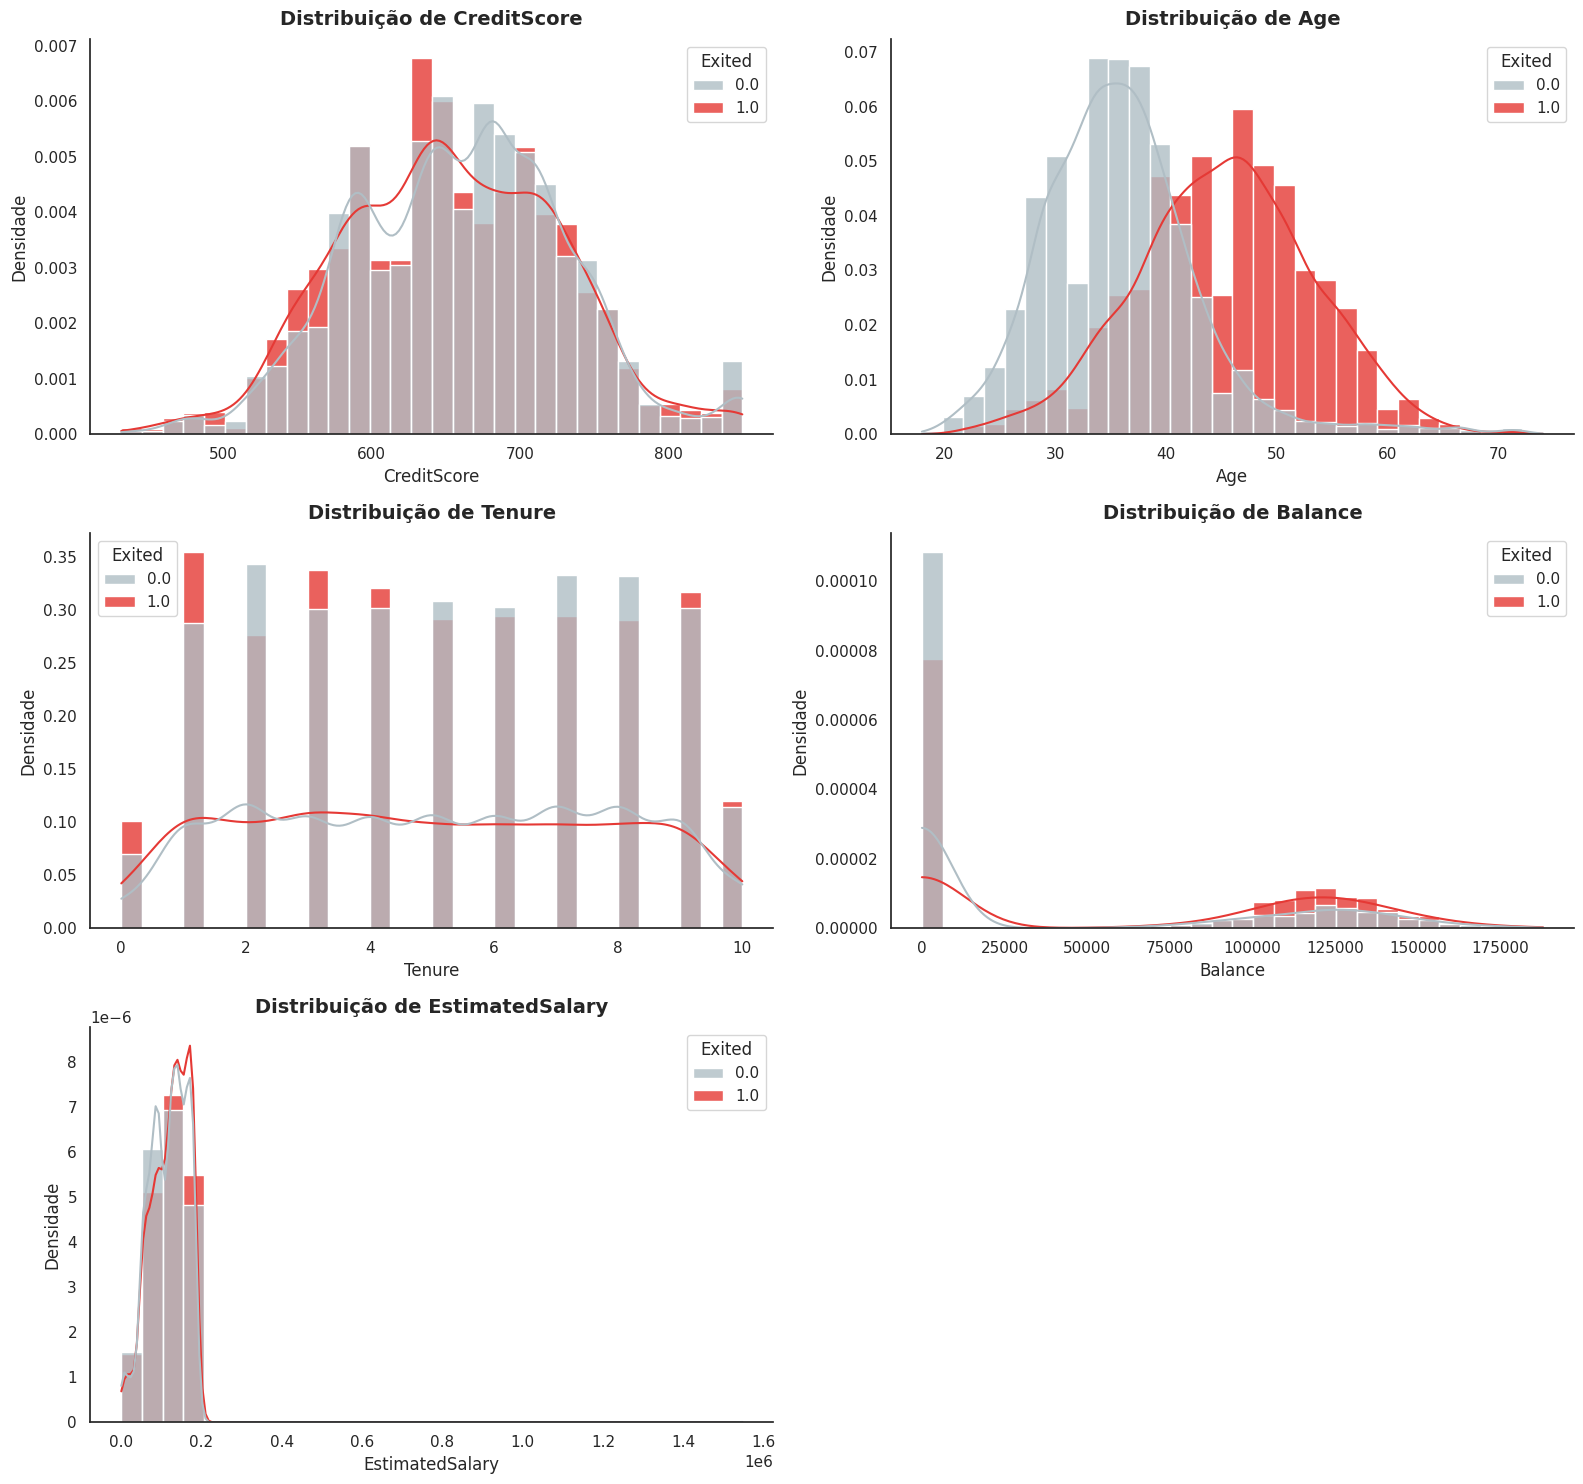

In [118]:
# Chama a função para plotar os gráficos das variáveis numéricas
plotar_distribuicao_numerica(df_train, cols_num)

## Diagnóstico Numérico e Fatores Críticos de Churn

### 1. Fuga de Capital (*Capital Leakage*)
* **Risco Crítico:** Clientes com saldos elevados (entre **100k e 150k**) apresentam a maior taxa de evasão.
* **Paradoxo da Retenção:** Clientes com saldo zerado são proporcionalmente os mais estáveis.
* **Impacto:** O banco sofre com a perda de AUM (*Assets Under Management*), mantendo contas de baixo valor residual e perdendo capital rentável.

### 2. Vulnerabilidade Geracional
* **Ponto de Alerta:** A faixa de **45 a 55 anos** concentra o risco máximo de saída.
* **Ponto Seguro:** O público jovem (<35 anos) é a âncora de estabilidade da instituição.
* **Hipótese:** O portfólio de produtos perde competitividade (em taxas ou atratividade) exatamente quando o cliente atinge a maturidade financeira.

### 3. Inércia de Relacionamento e Renda
* **Fatores Neutros:** Tempo de relacionamento (Tenure) e Salário Estimado (EstimatedSalary) mostraram-se estatisticamente homogeneos para prever a saída.
* **Insight:** O tempo de relacionamento não retém clientes, e a renda não prevê a evasão. O fator decisivo é o capital (saldo) efetivamente depositado na instituição.

**Conclusão da Análise:** O banco enfrenta um problema de **atratividade para o segmento Premium**. A retenção atual acontece por conveniência (baixo saldo), enquanto a perda acontece por performance (alto saldo). A estratégia de negócios precisa ser redirecionada urgentemente para blindar o público de meia-idade com alto patrimônio agregado.

### Verificação de OutLiers

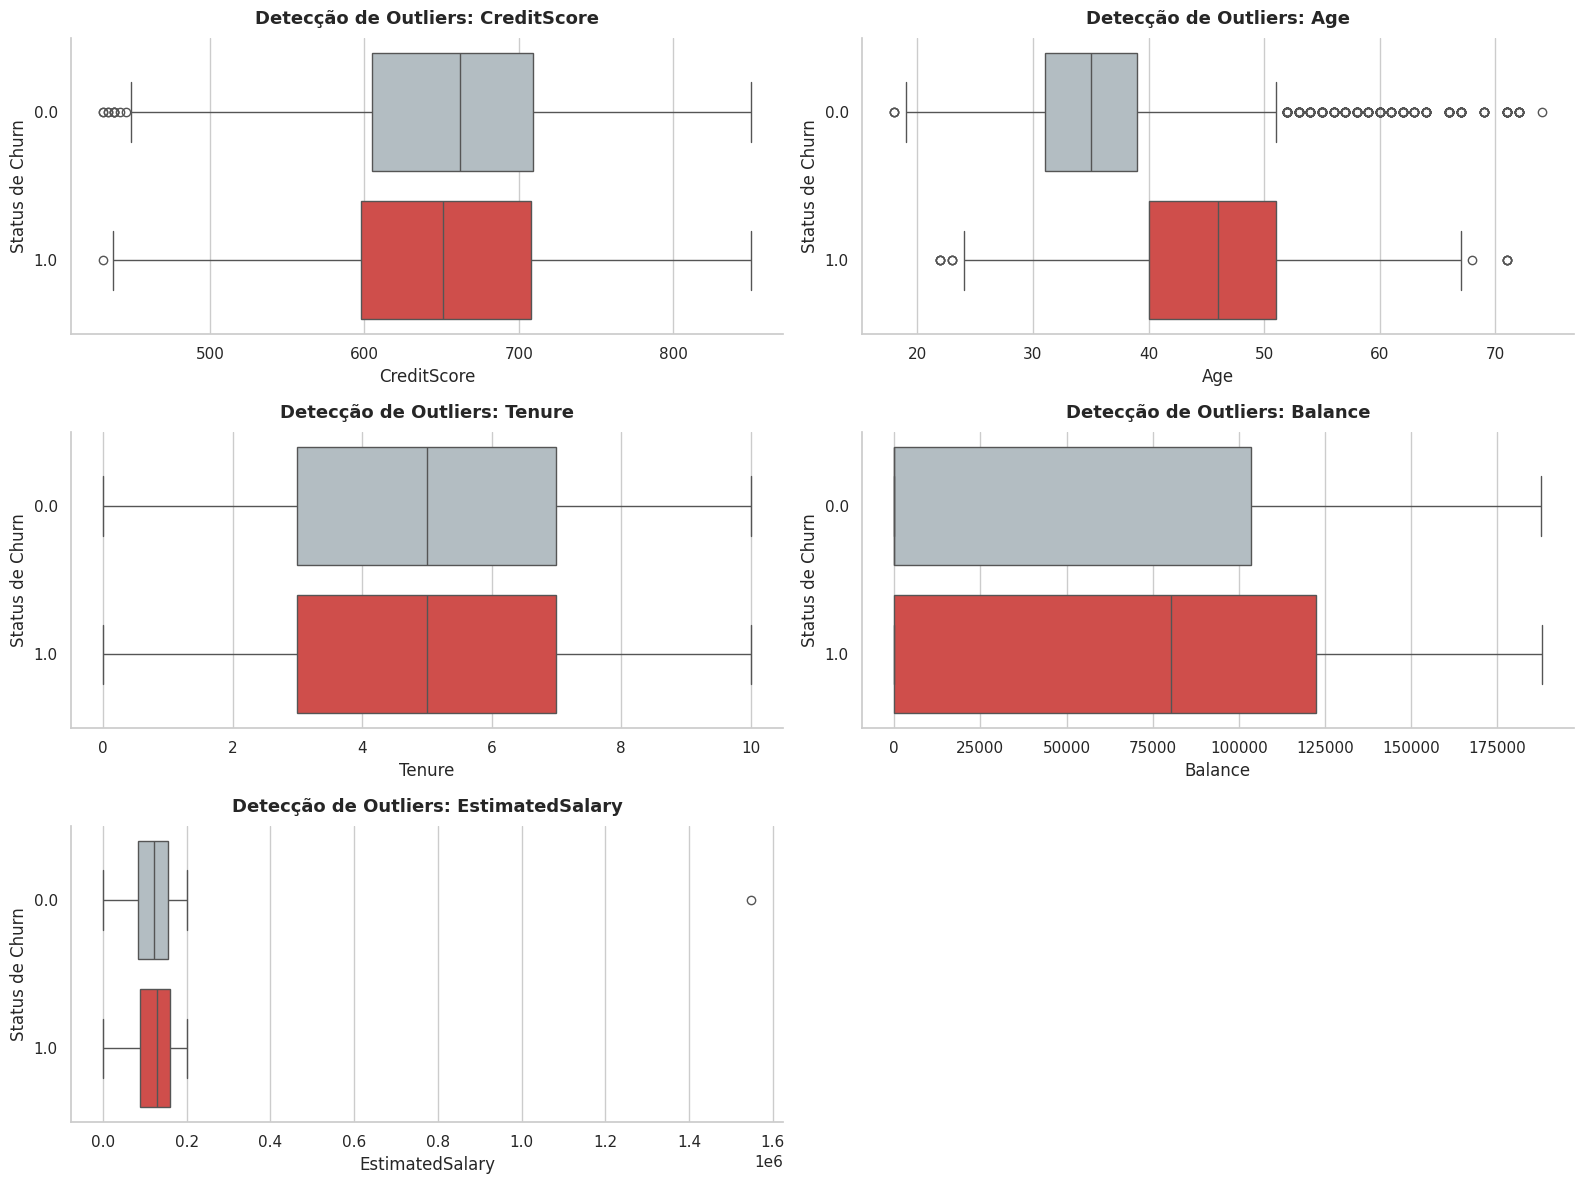

In [119]:
plotar_deteccao_outliers(df_train, cols_num)

In [120]:
# Filtrando o DataFrame para manter apenas quem ganha menos de 1 milhão
df_train = df_train[df_train['EstimatedSalary'] < 1000000]

# Verificando se a linha foi removida
print(f"Novo tamanho do dataset: {df_train.shape[0]} linhas")

Novo tamanho do dataset: 11999 linhas


A análise via Boxplots confirmou que os valores atípicos em Age, CreditScore e Balance são condizentes com a variabilidade real do negócio e serão mantidos.


Identificou-se uma única instância ruidosa em EstimatedSalary (> 1M), discrepante da distribuição geral (limite de 200k), que será removida para evitar distorções estatísticas no modelo.


## 4.2 Dados Categóricos:
Proporção de Churn em cada Grupo.


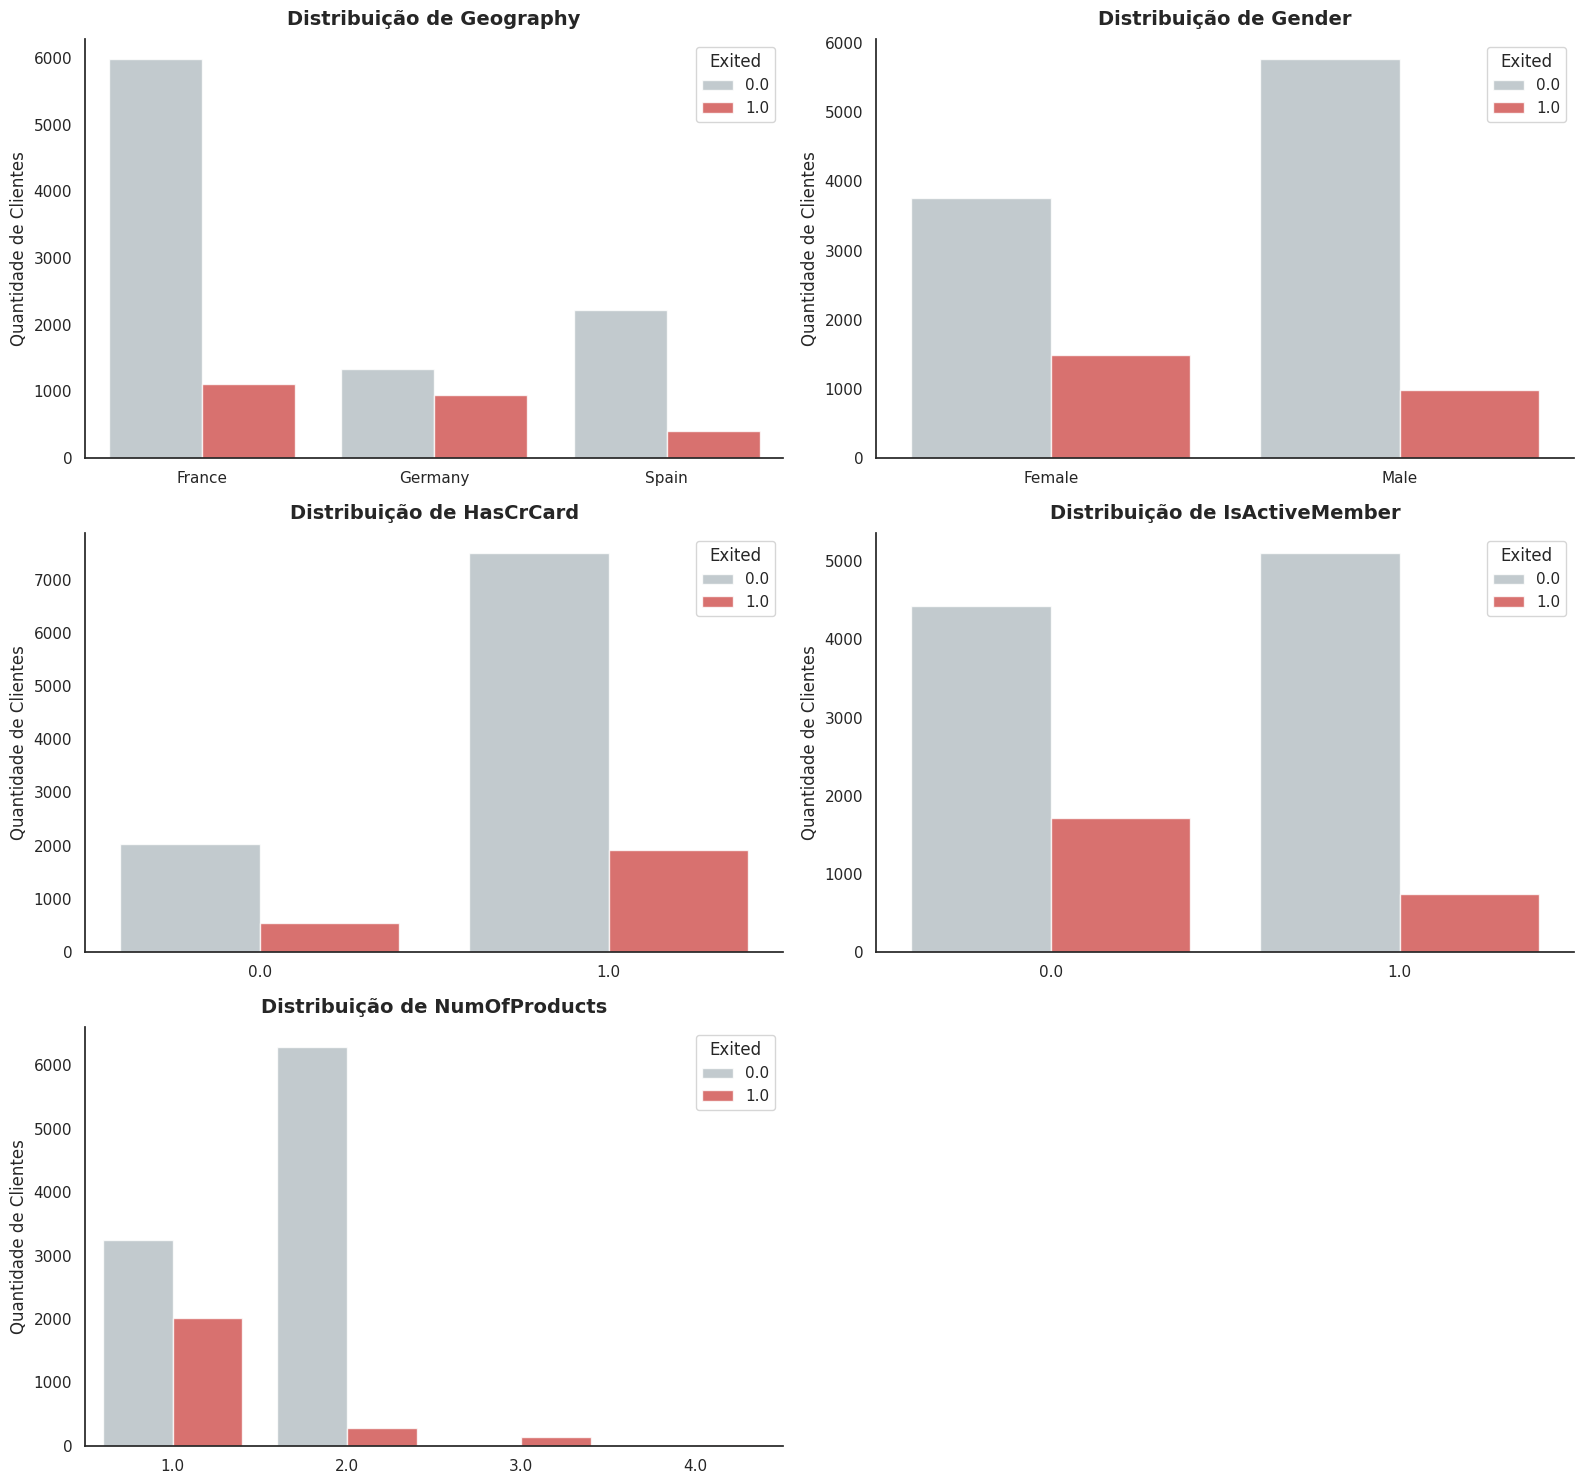

In [121]:
# Chama a função para plotar os gráficos das variáveis categóricas
plotar_distribuicao_categorica(df_train, cols_cat)

## Diagnóstico Categórico e Perfis de Risco

### 1. A "Armadilha" do Cross-Selling (Sobre Vendas)
* **Ponto Ideal (*Sweet Spot*):** Clientes com exatos **2 produtos** apresentam a maior taxa de fidelização.
* **Risco Crítico:** A posse de **3 ou 4 produtos** eleva a evasão para quase 100%.
* **Impacto:** Estratégias de venda agressiva ou excesso de complexidade geram atrito, motivando o cliente a encerrar o relacionamento.

### 2. Fissuras Regionais e de Gênero
* **Geografia:** A operação na **Alemanha** apresenta evasão drasticamente superior à da França e Espanha.
* **Gênero:** O público feminino possui uma propensão significativamente maior ao churn.
* **Hipótese:** Déficit de competitividade na oferta alemã (concorrência forte ou taxas ruins) e um portfólio que não atende plenamente às necessidades financeiras femininas.

### 3. Engajamento Real vs. Posse de Produtos
* **Sinal de Alerta:** A inatividade da conta (IsActiveMember) = 0 é o preditor categórico mais forte de saída.
* **Elemento Neutro:** A posse de um cartão de crédito (HasCrCard) não está retendo os clientes no banco.
* **Insight:** Fidelização exige uso contínuo por parte do cliente. Distribuir "produtos de prateleira" (como cartões não utilizados) não evita o churn.

> **Conclusão da Análise:** O perfil de **Risco Máximo** é o cliente **Alemão, Inativo e com 3+ produtos**. A instituição deve suspender políticas de empurrar múltiplos produtos sem garantir o uso diário da conta. A estratégia deve migrar imediatamente de *"vender mais"* para *"engajar melhor os produtos"*.

## Diagnóstico de Correlações (Heat Map)


In [122]:
corr_matrix = df_train.corr(numeric_only=True)

corr_matrix['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.460602
Balance,0.158140
EstimatedSalary,0.040131
HasCrCard,-0.004607
Tenure,-0.021193
CreditScore,-0.032615
IsActiveMember,-0.188951
NumOfProducts,-0.316467


### Diagnóstico de Correlação e Multicolinearidade

Para garantir a robustez do modelo de Machine Learning, precisamos responder a duas perguntas fundamentais:

**1. Quais variáveis influenciam linearmente a saída do cliente?**
Avaliando a correlação com o *Target* (Exited), notamos que relações estritamente lineares são fracas. Isso indica que o churn é um comportamento complexo e não-linear, exigindo modelos baseados em árvores (como XGBoost ou Random Forest).

**2. Nossos dados possuem informações matemáticas duplicadas?**
Abaixo, plotamos a matriz de multicolinearidade. O objetivo é garantir que não existam variáveis independentes altamente correlacionadas entre si (acima de 0.80), o que causaria redundância e prejudicaria o aprendizado do algoritmo.

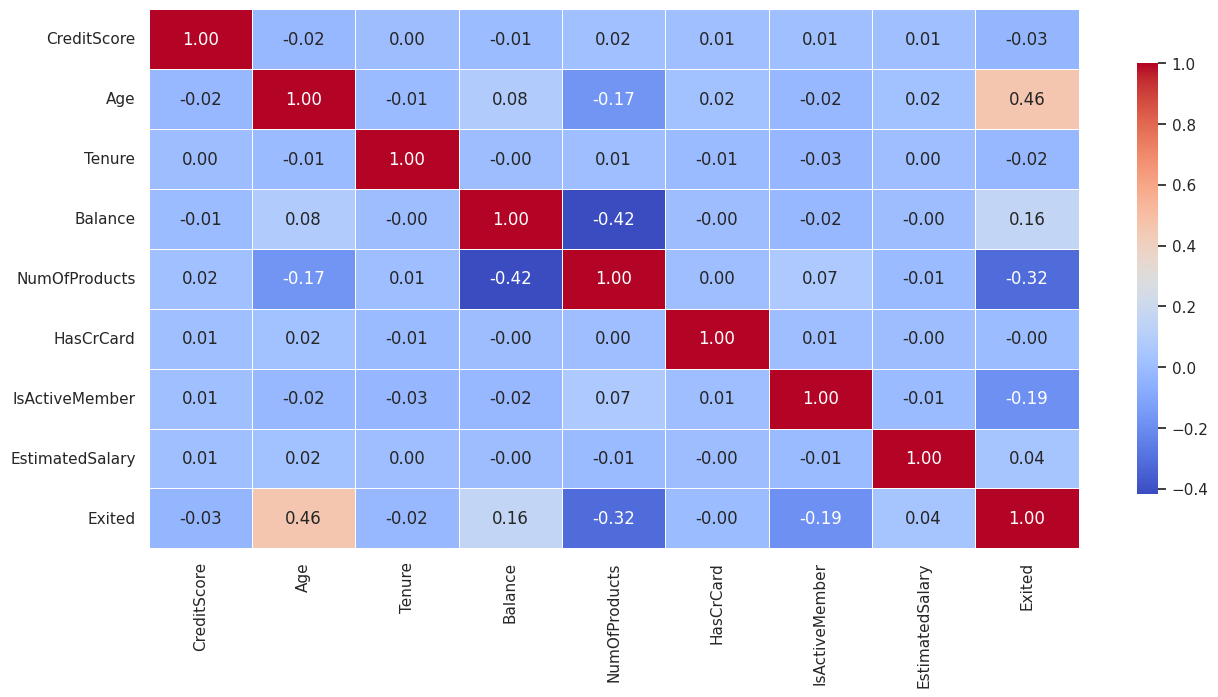

In [123]:
# Chama a função de mapa de Correlações
plotar_diagnostico_correlacao(df_train, cols_num)

Utilizando a Matriz de Correlação, buscamos validar duas premissas cruciais para a modelagem:

* **Quais variáveis influenciam linearmente a evasão?**
Observando a variável alvo (Exited), notamos que apenas (Age) apresenta um sinal moderado (0.46). A baixa correlação linear geral reforça que o churn é um problema de comportamento não linear, exigindo algoritmos baseados em árvores (como Random Forest, XGBoost ou CatBoost).

* **Existe redundância matemática nos dados?**
Avaliando o cruzamento interno entre as variáveis preditoras, não identificamos nenhum caso de multicolinearidade (correlações fortes, > 0.80). Os dados estão limpos de redundância e seguros para a modelagem.

# Conclusão da EDA e Escolha do Modelo Base

**O Problema Central:** O banco sofre uma hemorragia seletiva de capital, perdendo seus clientes financeiramente mais valiosos em vez dos menos rentáveis.

**O Perfil de Maior Risco:** A evasão concentra-se no público maduro (45 a 55 anos), com altos saldos na conta corrente, residentes na Alemanha e do gênero feminino.

**As Causas Principais:** A perda é impulsionada por falhas de engajamento (contas inativas) e atrito gerado por excesso de produtos. Tempo de relacionamento e alta renda provaram ser ineficazes para segurar o cliente.

**Estratégia de Retenção Recomendada:** A instituição deve abandonar a política de volume ("vender mais") e focar em ativar o uso contínuo da conta. O portfólio precisa ser readequado para o segmento premium, mirando o ("sweet spot") de exatos dois produtos por cliente.

## Escolha do modelo Base: CatBoost

A seleção do **CatBoost** (*Categorical Boosting*) como algoritmo preditivo principal fundamenta-se nas características intrínsecas dos dados reveladas durante a Análise Exploratória:

* **Tratamento Nativo de Categóricas:** Variáveis críticas de negócio (como Geography e Gender) são processadas diretamente pelo algoritmo, eliminando a necessidade de *One-Hot Encoding*. Isso evita a criação de matrizes esparsas e preserva a força original da informação.
* **Captura de Padrões Não Lineares:** Como evidenciado pelo *sweet spot* de 2 produtos e pela janela de risco de idade (45-55 anos), o churn não segue uma linha reta. A estrutura de árvores de decisão do CatBoost captura essas quebras de comportamento com perfeição.
* **Prevenção de Overfitting:** Sua arquitetura interna (*Ordered Boosting*) é altamente robusta contra o sobreajuste aos dados de treino, entregando alta performance preditiva logo de saída, com mínima necessidade de tunagem inicial de hiperparâmetros.